In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# quick sanity check
import src
print("src imported from:", src.__file__)


src imported from: /Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction/src/__init__.py


  model  horizon      rmse   rmse_lo   rmse_hi      smape   smape_lo  \
0   GRU        1  4.295841  4.162102  4.431222  19.183148  18.852154   
1   GRU        2  5.738901  5.553819  5.921492  24.907539  24.525509   
2   GRU        3  6.782080  6.593613  6.938892  29.416284  28.966499   
3   GRU        4  7.494905  7.319917  7.681122  32.677895  32.169256   
4   GRU        5  7.993737  7.815913  8.177340  35.128681  34.587686   
5   GRU        6  8.360008  8.162940  8.575089  37.069839  36.431876   
6   GRU        7  8.630629  8.410332  8.824246  38.559619  38.004514   
7   GRU        8  8.860242  8.635935  9.085747  39.491168  38.906831   
8   GRU        9  9.076087  8.874082  9.286007  40.319781  39.799864   
9   GRU       10  9.270406  9.069238  9.491566  41.187330  40.561736   

    smape_hi  
0  19.522138  
1  25.377929  
2  29.903998  
3  33.186399  
4  35.683846  
5  37.646289  
6  39.176886  
7  40.038692  
8  40.908325  
9  41.768016  
Saved: /Users/arthurreuss/code/Arthurreuss

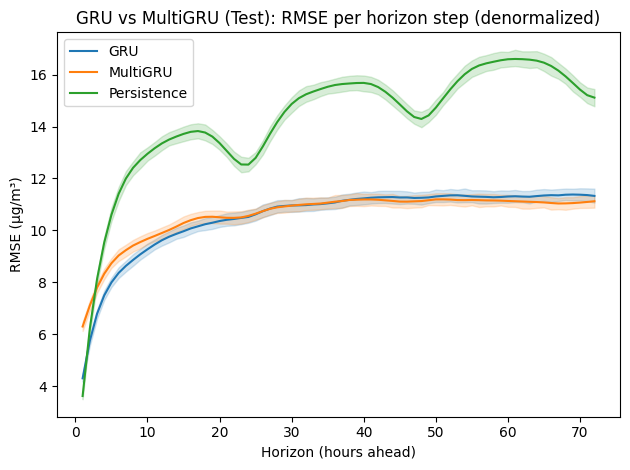

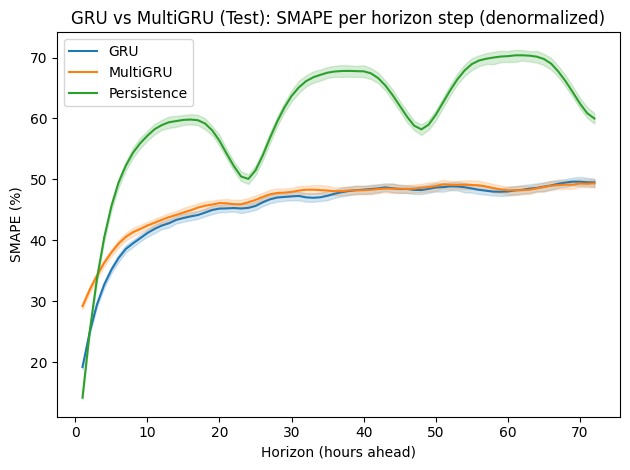

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional

import joblib
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
from torch.nn import Module
from torch.utils.data import DataLoader

from src.data.dataloaders import make_dataloader
from src.utils.scale import inverse_target

from src.models.gru import GRUForecast
from src.models.multi_gru import MultiGRUForecast  
from src.models.persistence import PersistenceModel

PROJECT_ROOT = Path("/Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction")
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")


def abs_path(p: str | Path) -> Path:
    p = Path(p)
    return p if p.is_absolute() else (PROJECT_ROOT / p)


def rmse(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2)).item()


def smape(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    denom = (torch.abs(y_true) + torch.abs(y_pred)) / 2.0
    val = torch.where(denom == 0, torch.zeros_like(denom), torch.abs(y_pred - y_true) / denom)
    return (val.mean() * 100.0).item()


def smape_per_sample(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    """
    Returns per-sample SMAPE values (NOT averaged), shape [N].
    Inputs expected shape [N].
    """
    denom = (torch.abs(y_true) + torch.abs(y_pred)) / 2.0
    val = torch.where(denom == 0, torch.zeros_like(denom), torch.abs(y_pred - y_true) / denom)
    return val * 100.0


def bootstrap_ci_mean(
    v: np.ndarray,
    *,
    n_boot: int = 300,
    alpha: float = 0.05,
    rng: np.random.Generator | None = None,
) -> tuple[float, float, float]:
    """
    Bootstrap CI for the mean of v.
    Returns: (mean, lo, hi)
    """
    if rng is None:
        rng = np.random.default_rng(0)

    v = np.asarray(v, dtype=np.float64)
    n = v.shape[0]
    if n == 0:
        return float("nan"), float("nan"), float("nan")

    mean = float(v.mean())
    idx = rng.integers(0, n, size=(n_boot, n))
    means = v[idx].mean(axis=1)

    lo = float(np.quantile(means, alpha / 2))
    hi = float(np.quantile(means, 1 - alpha / 2))
    return mean, lo, hi


def bootstrap_ci_rmse(
    err: np.ndarray,
    *,
    n_boot: int = 300,
    alpha: float = 0.05,
    rng: np.random.Generator | None = None,
) -> tuple[float, float, float]:
    """
    Bootstrap CI for RMSE given per-sample errors (pred-true), shape [N].
    Returns: (rmse, lo, hi)
    """
    if rng is None:
        rng = np.random.default_rng(0)

    err = np.asarray(err, dtype=np.float64)
    n = err.shape[0]
    if n == 0:
        return float("nan"), float("nan"), float("nan")

    rmse_val = float(np.sqrt(np.mean(err**2)))
    idx = rng.integers(0, n, size=(n_boot, n))
    rmses = np.sqrt(np.mean(err[idx] ** 2, axis=1))

    lo = float(np.quantile(rmses, alpha / 2))
    hi = float(np.quantile(rmses, 1 - alpha / 2))
    return rmse_val, lo, hi


def _to_target_2d(t: torch.Tensor, target_idx: int) -> torch.Tensor:
    """
    Accepts:
      [B,H] -> [B,H]
      [B,H,1] -> [B,H]
      [B,H,K] -> [B,H] selecting channel target_idx
    """
    if t.ndim == 2:
        return t
    if t.ndim == 3 and t.shape[-1] == 1:
        return t[..., 0]
    if t.ndim == 3 and t.shape[-1] > 1:
        return t[..., target_idx]
    raise ValueError(f"Expected [B,H] or [B,H,K] but got {tuple(t.shape)}")


@torch.no_grad()
def eval_persistence_per_horizon_denorm(
    model: "PersistenceModel",
    dataloader: DataLoader,
    device: str,
    *,
    scaler,
    numeric_cols: List[str],
    target_col: str,
    horizon: int,
    n_boot: int = 300,
    alpha: float = 0.05,
    seed: int = 0,
) -> Dict[str, List[float]]:
    y_true_all, y_pred_all = [], []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        y_hat = model.predict_batch(x, horizon)  # [B,H]

        y_2d = _to_target_2d(y, 0)         # [B,H]
        yhat_2d = _to_target_2d(y_hat, 0)  # [B,H]

        y_true_all.append(y_2d.detach().cpu())
        y_pred_all.append(yhat_2d.detach().cpu())

    y_true = torch.cat(y_true_all, dim=0)  # [N,H] normalized
    y_pred = torch.cat(y_pred_all, dim=0)  # [N,H] normalized
    H = y_true.shape[1]

    y_true_den = inverse_target(scaler, y_true, numeric_cols, target_col)  # [N,H]
    y_pred_den = inverse_target(scaler, y_pred, numeric_cols, target_col)  # [N,H]

    rng = np.random.default_rng(seed)

    rmse_mean, rmse_lo, rmse_hi = [], [], []
    sm_mean, sm_lo, sm_hi = [], [], []

    for h in range(H):
        yt = y_true_den[:, h].numpy()
        yp = y_pred_den[:, h].numpy()

        err = (yp - yt)
        r_m, r_l, r_h = bootstrap_ci_rmse(err, n_boot=n_boot, alpha=alpha, rng=rng)
        rmse_mean.append(r_m)
        rmse_lo.append(r_l)
        rmse_hi.append(r_h)

        sm = smape_per_sample(y_true_den[:, h], y_pred_den[:, h]).numpy()
        s_m, s_l, s_h = bootstrap_ci_mean(sm, n_boot=n_boot, alpha=alpha, rng=rng)
        sm_mean.append(s_m)
        sm_lo.append(s_l)
        sm_hi.append(s_h)

    return {
        "rmse": rmse_mean,
        "rmse_lo": rmse_lo,
        "rmse_hi": rmse_hi,
        "smape": sm_mean,
        "smape_lo": sm_lo,
        "smape_hi": sm_hi,
    }


@torch.no_grad()
def eval_per_horizon_denorm(
    model: Module,
    dataloader: DataLoader,
    device: str,
    *,
    scaler,
    numeric_cols: List[str],
    target_col: str,
    model_outputs_match: str,
    feature_cols: Optional[List[str]] = None,
    target_cols: Optional[List[str]] = None,
    n_boot: int = 300,
    alpha: float = 0.05,
    seed: int = 0,
) -> Dict[str, List[float]]:
    model.eval()
    y_true_all, y_pred_all = [], []

    if model_outputs_match == "single":
        target_idx = 0
    elif model_outputs_match == "feature_cols":
        if not feature_cols:
            raise ValueError("feature_cols must be provided when model_outputs_match='feature_cols'")
        target_idx = feature_cols.index(target_col)
    elif model_outputs_match == "target_cols":
        if not target_cols:
            raise ValueError("target_cols must be provided when model_outputs_match='target_cols'")
        target_idx = target_cols.index(target_col)
    else:
        raise ValueError("model_outputs_match must be one of: single, feature_cols, target_cols")

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        y_hat = model(x)

        y_2d = _to_target_2d(y, 0)
        yhat_2d = _to_target_2d(y_hat, target_idx)

        y_true_all.append(y_2d.detach().cpu())
        y_pred_all.append(yhat_2d.detach().cpu())

    y_true = torch.cat(y_true_all, dim=0)  # [N,H] normalized
    y_pred = torch.cat(y_pred_all, dim=0)  # [N,H] normalized
    H = y_true.shape[1]

    y_true_den = inverse_target(scaler, y_true, numeric_cols, target_col)  # [N,H]
    y_pred_den = inverse_target(scaler, y_pred, numeric_cols, target_col)  # [N,H]

    rng = np.random.default_rng(seed)

    rmse_mean, rmse_lo, rmse_hi = [], [], []
    sm_mean, sm_lo, sm_hi = [], [], []

    for h in range(H):
        yt = y_true_den[:, h].numpy()
        yp = y_pred_den[:, h].numpy()

        err = (yp - yt)
        r_m, r_l, r_h = bootstrap_ci_rmse(err, n_boot=n_boot, alpha=alpha, rng=rng)
        rmse_mean.append(r_m)
        rmse_lo.append(r_l)
        rmse_hi.append(r_h)

        sm = smape_per_sample(y_true_den[:, h], y_pred_den[:, h]).numpy()
        s_m, s_l, s_h = bootstrap_ci_mean(sm, n_boot=n_boot, alpha=alpha, rng=rng)
        sm_mean.append(s_m)
        sm_lo.append(s_l)
        sm_hi.append(s_h)

    return {
        "rmse": rmse_mean,
        "rmse_lo": rmse_lo,
        "rmse_hi": rmse_hi,
        "smape": sm_mean,
        "smape_lo": sm_lo,
        "smape_hi": sm_hi,
    }


def per_h_to_df(per_h: Dict[str, List[float]], *, label: str) -> pd.DataFrame:
    H = len(per_h["rmse"])
    return pd.DataFrame(
        {
            "model": label,
            "horizon": np.arange(1, H + 1),
            "rmse": per_h["rmse"],
            "rmse_lo": per_h["rmse_lo"],
            "rmse_hi": per_h["rmse_hi"],
            "smape": per_h["smape"],
            "smape_lo": per_h["smape_lo"],
            "smape_hi": per_h["smape_hi"],
        }
    )


def plot_compare(df_long: pd.DataFrame, *, title_prefix: str = "Test", band_alpha: float = 0.18):
    """
    Plots mean curves + translucent CI "stripes" (bands) instead of error bars.
    Uses fill_between with the same color as the line but with alpha.
    """

    # RMSE
    plt.figure()
    for m, g in df_long.groupby("model"):
        g = g.sort_values("horizon")
        x = g["horizon"].to_numpy()
        y = g["rmse"].to_numpy()
        lo = g["rmse_lo"].to_numpy()
        hi = g["rmse_hi"].to_numpy()

        (line,) = plt.plot(x, y, label=m)
        plt.fill_between(x, lo, hi, alpha=band_alpha, color=line.get_color())
    plt.xlabel("Horizon (hours ahead)")
    plt.ylabel("RMSE (µg/m³)")
    plt.title(f"{title_prefix}: RMSE per horizon step (denormalized)")
    plt.legend()
    plt.tight_layout()

    # SMAPE
    plt.figure()
    for m, g in df_long.groupby("model"):
        g = g.sort_values("horizon")
        x = g["horizon"].to_numpy()
        y = g["smape"].to_numpy()
        lo = g["smape_lo"].to_numpy()
        hi = g["smape_hi"].to_numpy()

        (line,) = plt.plot(x, y, label=m)
        plt.fill_between(x, lo, hi, alpha=band_alpha, color=line.get_color())
    plt.xlabel("Horizon (hours ahead)")
    plt.ylabel("SMAPE (%)")
    plt.title(f"{title_prefix}: SMAPE per horizon step (denormalized)")
    plt.legend()
    plt.tight_layout()

    plt.show()


def load_state_dict_flexible(path: Path, device: str) -> dict:
    state = torch.load(str(path), map_location=device)
    if isinstance(state, dict):
        for k in ["state_dict", "model_state_dict", "model_state", "model"]:
            if k in state and isinstance(state[k], dict):
                return state[k]
    return state


def main():
    cfg_path = PROJECT_ROOT / "config.yaml"
    with open(cfg_path, "r") as f:
        cfg = yaml.safe_load(f)

    data_cfg = cfg["data"]
    train_path = abs_path(data_cfg["train_path"])
    test_path = abs_path(data_cfg["test_path"])

    feature_cols = data_cfg["feature_cols"]
    target_col = data_cfg["target_col"]
    input_length = data_cfg["input_length"]
    horizon = data_cfg["horizon"]
    input_size = len(feature_cols)

    test_loader = make_dataloader(
        str(test_path),
        feature_cols,
        target_col,
        input_length,
        horizon,
        batch_size=cfg["training"]["batch_size"],
        shuffle=False,
    )

    scaler_path_cfg = data_cfg.get("scaler_path")
    if not scaler_path_cfg:
        raise ValueError("Need data.scaler_path to compute denormalized metrics.")
    scaler = joblib.load(str(abs_path(scaler_path_cfg)))

    if "numeric_cols" in data_cfg and data_cfg["numeric_cols"]:
        numeric_cols = data_cfg["numeric_cols"]
    else:
        df_train = pd.read_parquet(str(train_path))
        numeric_cols = df_train.select_dtypes(include=["number"]).columns.tolist()

    results_dir = PROJECT_ROOT / "results"

    gru_ckpt = results_dir / "gru_best.pt"
    if not gru_ckpt.exists():
        raise FileNotFoundError(f"Missing: {gru_ckpt}")

    gru = GRUForecast(
        input_size=input_size,
        hidden_size=112,
        num_layers=1,
        horizon=horizon,
        dropout=0.38,
    ).to(DEVICE)
    gru.load_state_dict(load_state_dict_flexible(gru_ckpt, DEVICE))

    multigru_ckpt = results_dir / "multi_gru_best.pt"
    if not multigru_ckpt.exists():
        raise FileNotFoundError(f"Missing: {multigru_ckpt}")

    target_cols = data_cfg["target_cols"]
    if target_col not in target_cols:
        raise ValueError(f"target_col '{target_col}' not found in target_cols: {target_cols}")

    multigru = MultiGRUForecast(
        input_size=input_size,
        target_cols=target_cols,
        horizon=horizon,
        shared_hidden_size=112,
        branch_hidden_size=64,
        num_layers=1,
        dropout=0.44,
    ).to(DEVICE)
    multigru.load_state_dict(load_state_dict_flexible(multigru_ckpt, DEVICE))

    per_h_gru = eval_per_horizon_denorm(
        gru,
        test_loader,
        DEVICE,
        scaler=scaler,
        numeric_cols=numeric_cols,
        target_col=target_col,
        model_outputs_match="single",
        n_boot=300,
        alpha=0.05,
        seed=0,
    )

    per_h_mgru = eval_per_horizon_denorm(
        multigru,
        test_loader,
        DEVICE,
        scaler=scaler,
        numeric_cols=numeric_cols,
        target_col=target_col,
        model_outputs_match="target_cols",
        target_cols=target_cols,
        n_boot=300,
        alpha=0.05,
        seed=0,
    )

    target_feature_index = feature_cols.index(target_col)
    persistence = PersistenceModel(target_feature_index=target_feature_index)

    per_h_pers = eval_persistence_per_horizon_denorm(
        persistence,
        test_loader,
        DEVICE,
        scaler=scaler,
        numeric_cols=numeric_cols,
        target_col=target_col,
        horizon=horizon,
        n_boot=300,
        alpha=0.05,
        seed=0,
    )

    df_long = pd.concat(
        [
            per_h_to_df(per_h_gru, label="GRU"),
            per_h_to_df(per_h_mgru, label="MultiGRU"),
            per_h_to_df(per_h_pers, label="Persistence"),
        ],
        ignore_index=True,
    )

    out_csv = results_dir / "gru_vs_multigru_test_per_horizon_denorm.csv"
    df_long.to_csv(out_csv, index=False)
    print(df_long.head(10))
    print(f"Saved: {out_csv}")

    plot_compare(df_long, title_prefix="GRU vs MultiGRU (Test)", band_alpha=0.18)


if __name__ == "__main__":
    main()
